# Micrograd

Let's build Andrej Karpathy's Micrograd from scratch!

Steps:
1. Engine -> Value class ✅
2. Draw equations
3. Test manual gradient calculations
4. Automatic gradient
5. Neuron, layer and MLP classes



### Define "Value" class

In [281]:
"""Value class
This class is the data structure for storing variables
of the code

Returns:
    Value: A new object with type Value
    
    TODO: MOVE TO SEPARATE MODULE
"""

from __future__ import annotations


class Value:
    
    def __init__(self, data: float, name='', children=[], tag=None, operator=None):
        self.data = data
        self.name = name
        self.tag = tag if tag else self.name
        self._op = operator
        self._prev = children
    
    def __repr__(self):
        return f"Value({self.name} | data={self.data}) | tag={self.tag} | op={self._op} | children={[c.name for c in self._prev] if self._prev else []}"
    
    def __add__(self, other: Value) -> Value:
        return Value(self.data + other.data, tag=f"{self.name}+{other.name}", operator='+', children=[self, other])
    
    def __mul__(self, other: Value) -> Value:
        return Value(self.data * other.data, tag=f"{self.name}.{other.name}", operator='*', children=[self, other])
    
    def __pow__(self, other: Value) -> Value:
        return Value(self.data ** other.data, tag=f"{self.name}**{other.name}", operator='**', children=[self, other])
    
    
    def draw_node(self, format="SVG", rankdir="LR"):
        nodes, edges = set(), set()
        def trace(root) -> tuple[set[Value, set[Value]]]:
            def build(n: Value):
                nodes.add(n)
                for child in n._prev:
                    edges.add((child.name, n.name))
                    build(child)
            build(root)
            
        dot = graphviz.Digraph('computation_graph', comment='Graph of Computations', graph_attr={'rankdir': rankdir}, format=format)
        
        trace(self)
        for n in nodes:
            dot.node(name=n.name, label=f"{{{n.name} | data={n.data:.4f} | tag={n.tag} }}", shape='record')    
            if n._op:
                dot.node(name=n.name+"_op", label=n._op, )
                dot.edge(tail_name=n.name+"_op", head_name=n.name)
                
        for e in edges:
            tail_node, head_node = e
            dot.edge(tail_name=tail_node, head_name=head_node+"_op")
        return dot
        

In [271]:
# utils.py
import graphviz


def trace(root) -> tuple[set[Value, set[Value]]]:
    nodes, edges = set(), set()
    def build(n: Value):
        nodes.add(n)
        for child in n._prev:
            edges.add((child.name, n.name))
            build(child)
    build(root)
    return nodes, edges
        
            
def print_tree(root):
    nodes, edges = trace(root)
    print("========= NODES ===========")
    for ind, val in enumerate(nodes):
        print(f"{ind} - {val}")
    print(" ========== EDGES =========")
    for ind, val in enumerate(edges):
        print(f"{ind} - {val}")
      
def draw_computation_graph(root: Value) -> graphviz.Digraph:
    dot = graphviz.Digraph('computation_graph', comment='Graph of Computations', graph_attr={'rankdir': 'LR'}, format='SVG')
    nodes, edges = trace(root)
    for n in nodes:
        dot.node(name=n.name, label=f"{{{n.name} | data={n.data:.4f} | tag={n.tag} }}", shape='record')    
        if n._op:
            dot.node(name=n.name+"_op", label=n._op, )
            dot.edge(tail_name=n.name+"_op", head_name=n.name)
    for tail, head in edges:
        dot.edge(tail_name=tail, head_name=head+"_op")
    return dot
        


test the Value class

In [272]:
a = Value(4.5, 'a')
b = Value(2.75, 'b')
print(a)
print(a + b)
print(a * b)
print(a**b)

Value(a | data=4.5) | tag=a | op=None | children=[]
Value( | data=7.25) | tag=a+b | op=+ | children=['a', 'b']
Value( | data=12.375) | tag=a.b | op=* | children=['a', 'b']
Value( | data=62.5654269961787) | tag=a**b | op=** | children=['a', 'b']


## Draw Computation Diagram

To use graphviz, it's necessary to install the system software on the OS as wells as the python package.

- `$ sudo apt install graphviz`

- `$ pip install graphviz`

In [273]:
a = Value(4.5, 'a')
b = Value(2.75, 'b')
c = Value(5.3, 'c')
d = Value(4.0, 'd')
h1 = a + b; h1.name = 'h1'
h2 = h1 * c; h2.name = 'h2'
h3 = h2 ** d; h3.name = 'h3'

In [275]:
a = Value(4.5, 'a')
b = Value(2.75, 'b')
c = Value(5.3, 'c')
d = Value(4.0, 'd')
h1 = a + b; h1.name = 'h1'
h2 = h1 * c; h2.name = 'h2'
h3 = h2 ** d; h3.name = 'h3'

In [276]:
def trace(root) -> tuple[set[Value, set[Value]]]:
    nodes, edges = set(), set()
    def build(n: Value):
        nodes.add(n)
        for child in n._prev:
            edges.add((child.name, n.name))
            build(child)
    build(root)
    return nodes, edges
        
            
def print_tree(root):
    nodes, edges = trace(root)
    print("========= NODES ===========")
    for ind, val in enumerate(nodes):
        print(f"{ind} - {val}")
    print(" ========== EDGES =========")
    for ind, val in enumerate(edges):
        print(f"{ind} - {val}")

In [277]:
trace(h3)
print_tree(h3)

========= NODES ===========
0 - Value(d | data=4.0) | tag=d | op=None | children=[]
1 - Value(h1 | data=7.25) | tag=a+b | op=+ | children=['a', 'b']
2 - Value(h2 | data=38.425) | tag=h1.c | op=* | children=['h1', 'c']
3 - Value(c | data=5.3) | tag=c | op=None | children=[]
4 - Value(h3 | data=2179995.03600039) | tag=h2**d | op=** | children=['h2', 'd']
5 - Value(b | data=2.75) | tag=b | op=None | children=[]
6 - Value(a | data=4.5) | tag=a | op=None | children=[]
 ========== EDGES =========
0 - ('c', 'h2')
1 - ('h1', 'h2')
2 - ('h2', 'h3')
3 - ('b', 'h1')
4 - ('d', 'h3')
5 - ('a', 'h1')


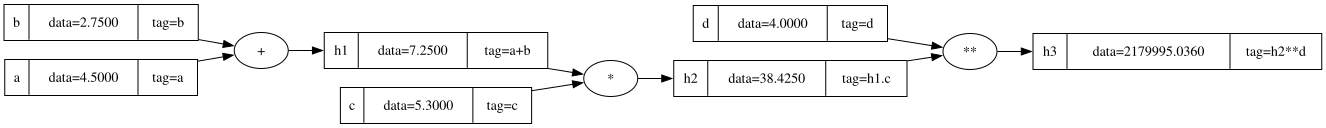

In [280]:
draw_computation_graph(h3)

## Manual Gradient

Compute gradients manually and test the propagation of the gradients in the computation graph